In [1]:
from boututils.datafile import DataFile
from boutdata.collect import collect
import pandas as pd
import numpy as np

import os, sys, pathlib
import platform
import traceback
import xarray as xr
import xbout
from pathlib import Path
import xhermes as xh

sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/sdtools"))
# sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/my_notebooks/notebooks/hermes-3/transients"))
sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/notebooks/hermes-3/general_functions"))


from plotting_functions import *
from convergence_functions import * 

from hermes3.case_db import *
from hermes3.casedeck import*
from hermes3.load import *
from hermes3.named_selections import *
from hermes3.plotting import *
from hermes3.grid_fields import *
from hermes3.accessors import *
from hermes3.utils import *
from hermes3.fluxes import *
from hermes3.selectors import *
from hermes3.front_tracking import *
from hermes3.neutral_transport import *

# from code_comparison.code_comparison import *
from code_comparison.solps_pp import *
from code_comparison.solps_variables import *
# from code_comparison.viewer_2d import *


from solps_funcs import *

# from hermes3.balance1d import *

# plt.style.use('ggplot')
plt.rcParams.update({'font.size': 10})
linewidth = 3
markersize = 15



# plt.style.use('ggplot')
mpl.style.use('default')
mpl.rcParams["axes.edgecolor"] = "black"
mpl.rcParams["axes.linewidth"] = 1
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['axes.grid'] = True
mpl.rcParams.update({'font.size': 16})



%load_ext autoreload
%autoreload 2


In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# I/O

In [3]:
cs = Load.case_1D('/Users/lloyd/Documents/hermes_dir/hermes-3/build-minmod-dev-reservoir/examples/tokamak-1D/reservoir_test_restart', use_squash=True).ds

- Looking for squash file
- Squash file found. squash date 01/06/2026, 16:31:01, dmp file date 01/06/2026, 16:00:23
Replacing guard cells


In [4]:
solps_case = SOLPScase('/Users/lloyd/Documents/hermes_dir/york-step_analysis_intro/data/solps')

Detachment front found at R=0.959 m, Z=-1.809 m
Te at front: 4.93 eV (threshold: 5 eV)
Poloidal grid index: 159


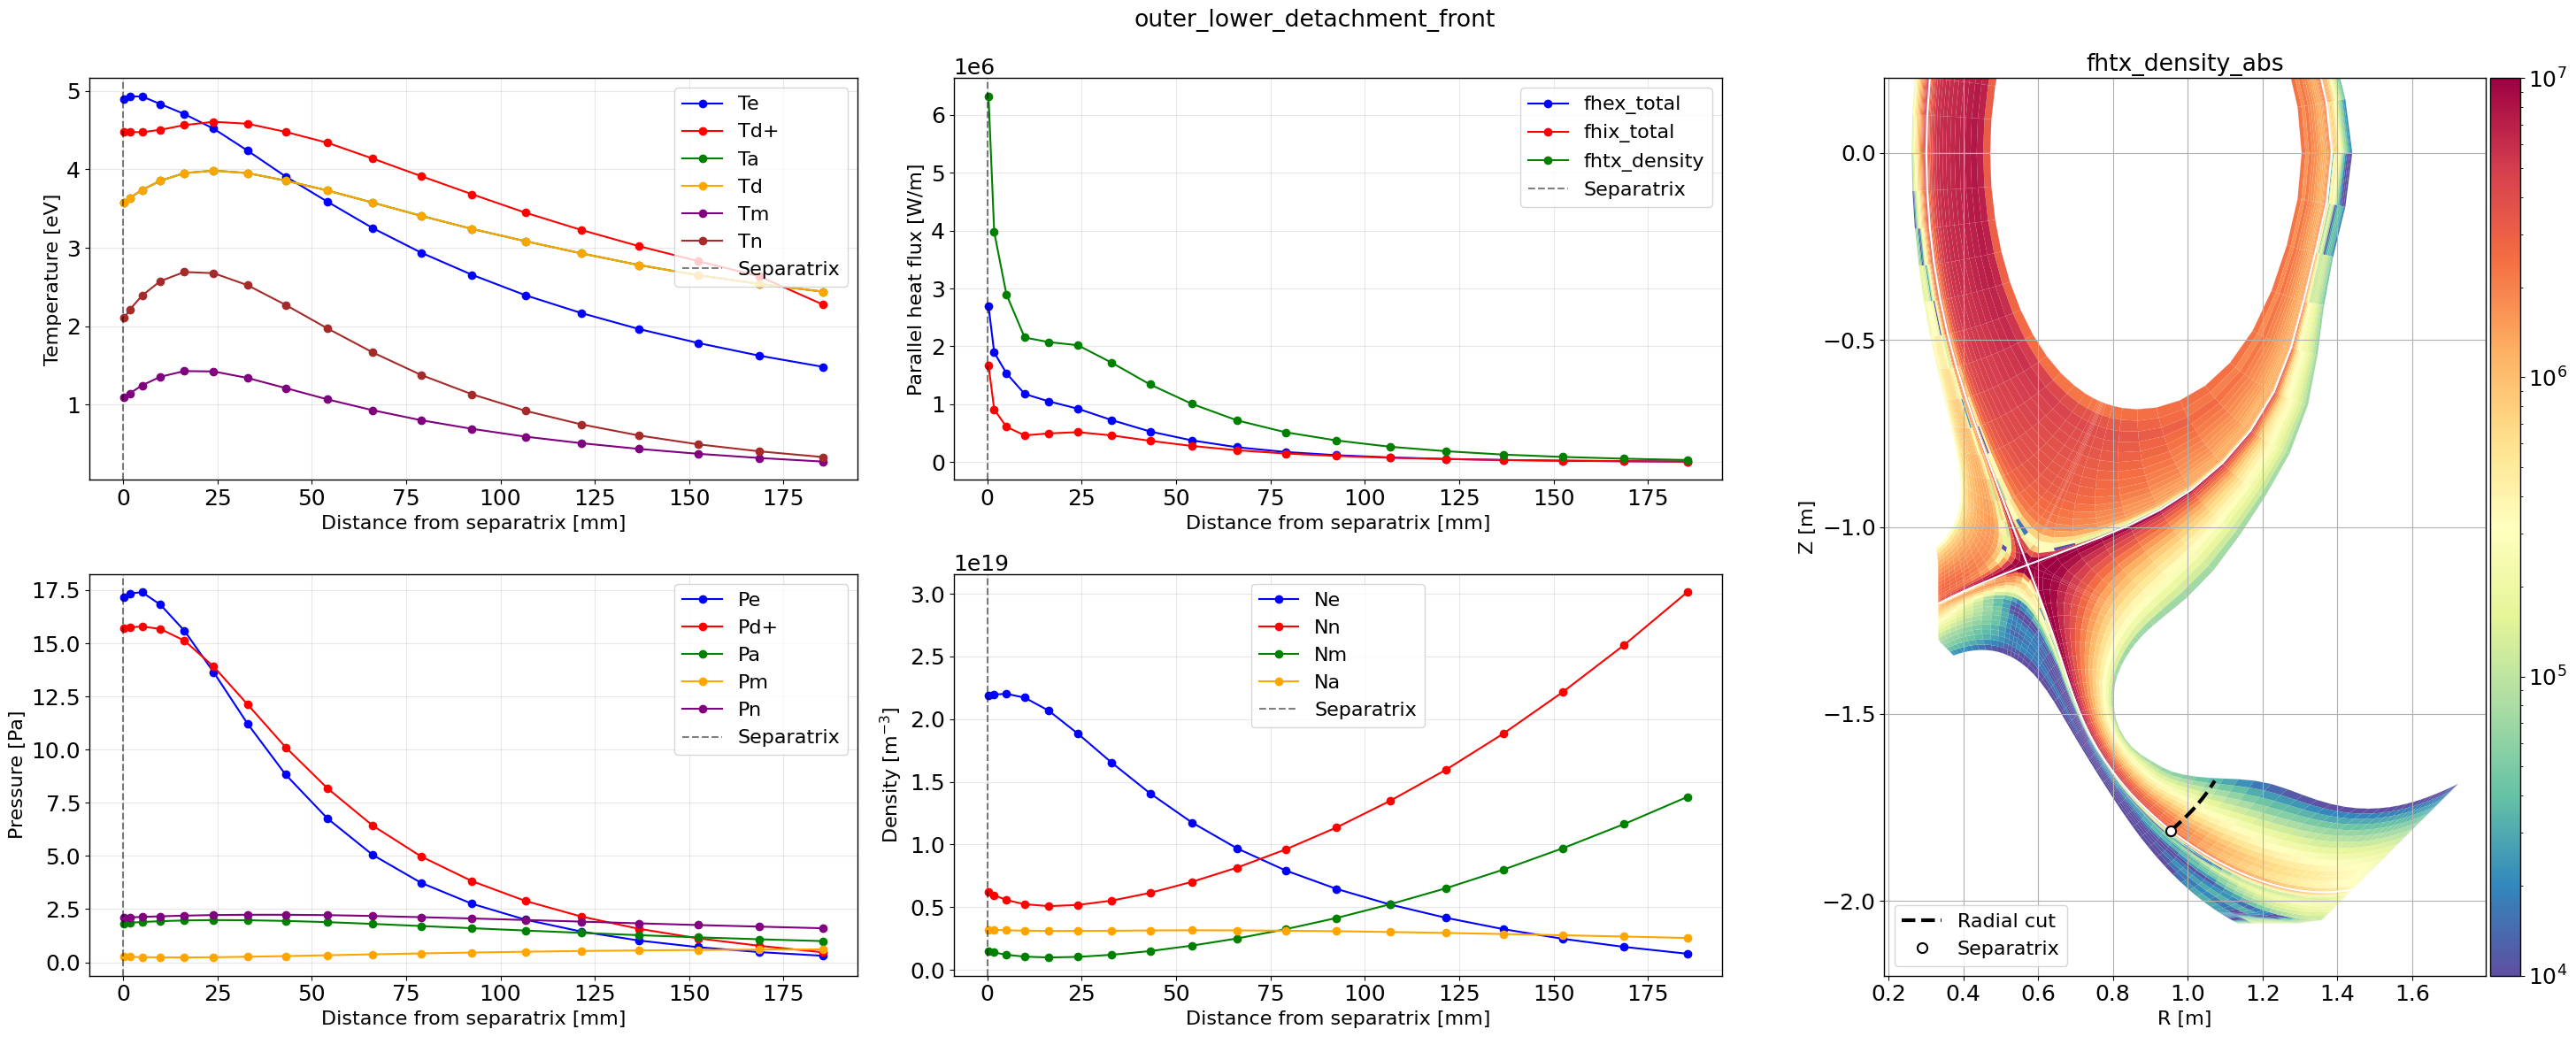

In [5]:
plot_radial_profiles(solps_case, region = 'outer_lower_detachment_front', poloidal_offset = 0, zoom = False, param_2d = 'fhtx_density_abs', grid_only = False, cfr_only = True, vmin = 1e4, vmax = 1e7)

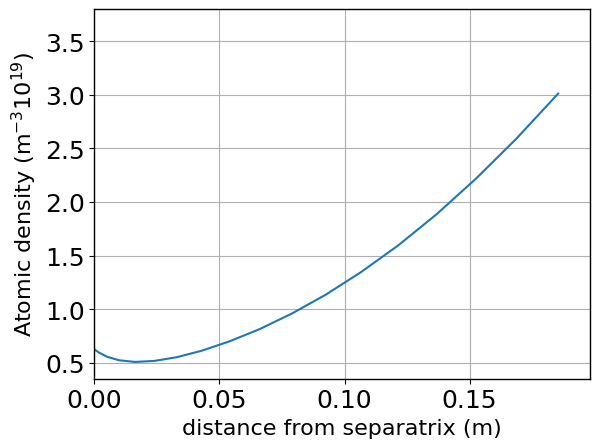

In [12]:
fline = solps_case.get_1d_radial_data(params = 'Nn', region = 'outer_lower_detachment_front')


fig,ax = plt.subplots()
ax.plot(fline['dist'], fline['Nn']*1e-19)
ax.set_ylabel('Atomic density (m$^{-3} 10^{19}$)')
ax.set_xlabel(r'distance from separatrix (m)')
# ax.set_title('Atomic density along the detachment front')
# ax.set_yscale('log')
ax.set_xbound(0, None)




In [7]:
print(cs.data_vars)

Data variables:
    Bxy                                         (pos) float64 3kB dask.array<chunksize=(404,), meta=np.ndarray>
    Ed+_VgradP                                  (t, pos) float64 90kB dask.array<chunksize=(1, 404), meta=np.ndarray>
    Ed+_iz                                      (t, pos) float64 90kB dask.array<chunksize=(1, 404), meta=np.ndarray>
    Ed+_rec                                     (t, pos) float64 90kB dask.array<chunksize=(1, 404), meta=np.ndarray>
    Ed_VgradP                                   (t, pos) float64 90kB dask.array<chunksize=(1, 404), meta=np.ndarray>
    Ed_rsv_div_pfr                              (t, pos) float64 90kB dask.array<chunksize=(1, 404), meta=np.ndarray>
    Ed_rsv_div_sol                              (t, pos) float64 90kB dask.array<chunksize=(1, 404), meta=np.ndarray>
    Ed_rsv_main_sol                             (t, pos) float64 90kB dask.array<chunksize=(1, 404), meta=np.ndarray>
    Ed_target_recycle                         

Text(0, 0.5, 'Cell side area (m$^2$)')

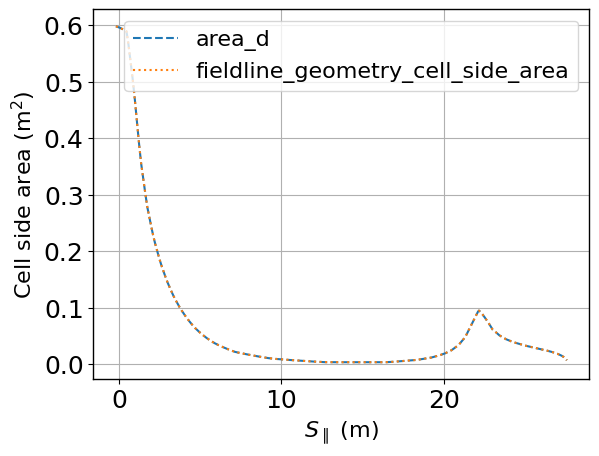

In [8]:
fig, ax = plt.subplots()

ax.plot(cs['pos'], cs['area_d'], label='area_d', linestyle='--')
ax.plot(cs['pos'], cs['fieldline_geometry_cell_side_area'], label='fieldline_geometry_cell_side_area', linestyle=':')

ax.legend()
ax.set_xlabel(r'$S_\parallel$ (m)')
ax.set_ylabel('Cell side area (m$^2$)')
# ax.set_title('Area of the domain')
# ax.set_yscale('log')
# ax.set_xlim(0, 0.02)




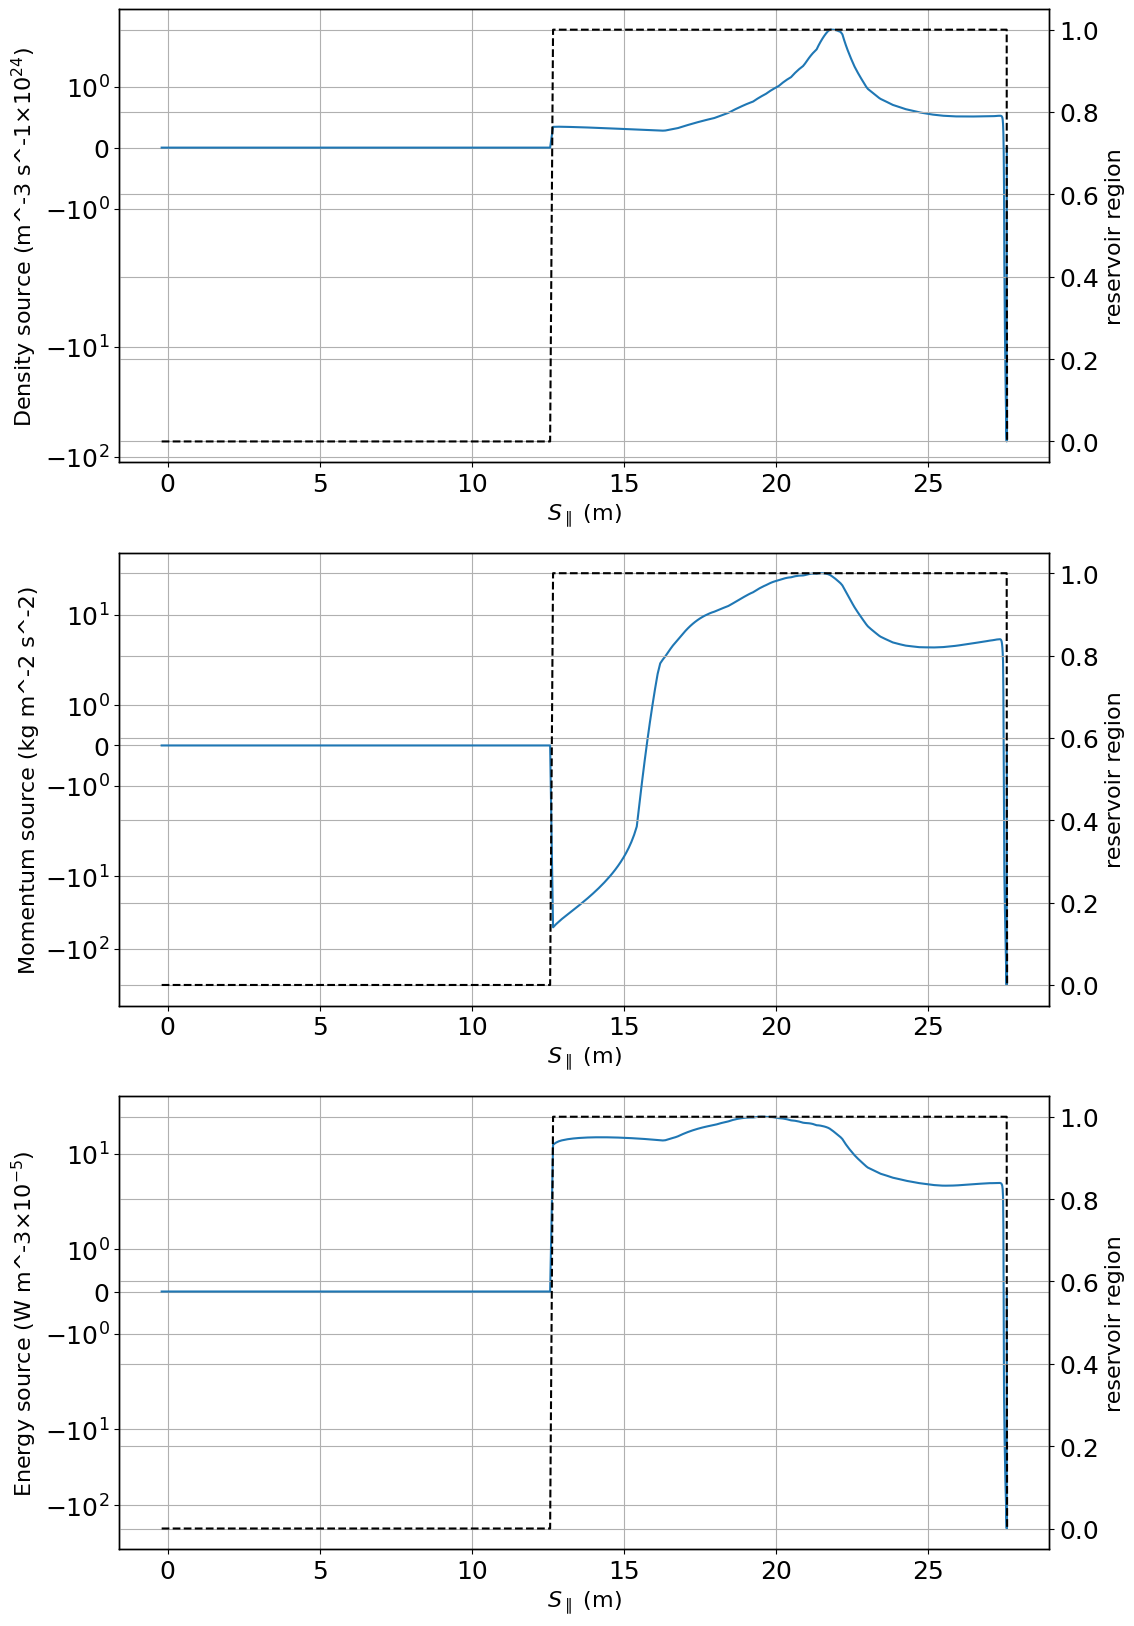

In [ ]:
fig, ax = plt.subplots(3,1, figsize=(12, 20))
ax12 = ax[0].twinx()
ax12.plot(cs['pos'], cs['rsv_div_sol_d'], label='reservoir region', linestyle='--', color='black')
ax12.set_ylabel('reservoir region')
ax[0].plot(cs['pos'], cs.isel(t=-1)['Sd_rsv_div_sol']*1e-24, label='Density source', linestyle='-')
ax[0].set_xlabel(r'$S_\parallel$ (m)')
ax[0].set_ylabel(f'({cs["Sd_rsv_div_sol"].units}' + r'$\times 10^{24}$)')

ax22 = ax[1].twinx()
ax22.plot(cs['pos'], cs['rsv_div_sol_d'], label='reservoir region', linestyle='--', color='black')
ax22.set_ylabel('reservoir region')
ax[1].plot(cs['pos'], cs.isel(t=-1)['Fd_rsv_div_sol'], label='Momentum source', linestyle='-')
ax[1].set_xlabel(r'$S_\parallel$ (m)')
ax[1].set_ylabel(f'({cs["Fd_rsv_div_sol"].units})')

ax32 = ax[2].twinx()
ax32.plot(cs['pos'], cs['rsv_div_sol_d'], label='reservoir region', linestyle='--', color='black')
ax32.set_ylabel('reservoir region')
ax[2].plot(cs['pos'], cs.isel(t=-1)['Ed_rsv_div_sol']*1e-5, label='Energy source', linestyle='-')
ax[2].set_xlabel(r'$S_\parallel$ (m)')
ax[2].set_ylabel(f'({cs["Ed_rsv_div_sol"].units}' + r'$\times 10^{-5}$)')

ax[0].set_yscale('symlog')
ax[1].set_yscale('symlog')
ax[2].set_yscale('symlog')


ax[0].legend()
ax[1].legend()
ax[2].legend()